# About the data
link -> https://archive.ics.uci.edu/dataset/352/online+retail
This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts.   
Many customers of the company are wholesalers.  

InvoiceNo -> starts with letter 'c', it indicates a cancellation. 


In [4]:
import pandas as pd 

In [5]:
df = pd.read_excel("data/Online_Retail.xlsx")

# EDA

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.tail(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df = df.dropna(subset=["CustomerID"])

In [12]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].count()

InvoiceNo      8905
StockCode      8905
Description    8905
Quantity       8905
InvoiceDate    8905
UnitPrice      8905
CustomerID     8905
Country        8905
dtype: int64

In [13]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [14]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [15]:
df.columns = [c.strip() for c in df.columns]

In [16]:
df.size

3183392

In [17]:
df[(df["UnitPrice"] > 0) & (df["Quantity"] > 0)].count()

InvoiceNo      397884
StockCode      397884
Description    397884
Quantity       397884
InvoiceDate    397884
UnitPrice      397884
CustomerID     397884
Country        397884
dtype: int64

In [18]:
df = df[(df["UnitPrice"] > 0) & (df["Quantity"] > 0)]

In [19]:
df.shape

(397884, 8)

# create revenue column

In [20]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [21]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [22]:
# understanding the customers

In [23]:
#number of customers = 
n_customers= df["CustomerID"].nunique()
n_invoices = df["InvoiceNo"].nunique()

In [24]:
print("unique customers: ",n_customers) 
print("unique invoices ",n_invoices) 

unique customers:  4338
unique invoices  18532


# revenue distribution

In [25]:
customer_revenue = df.groupby("CustomerID")["Revenue"].sum()

In [2]:
import matplotlib.pyplot as plt

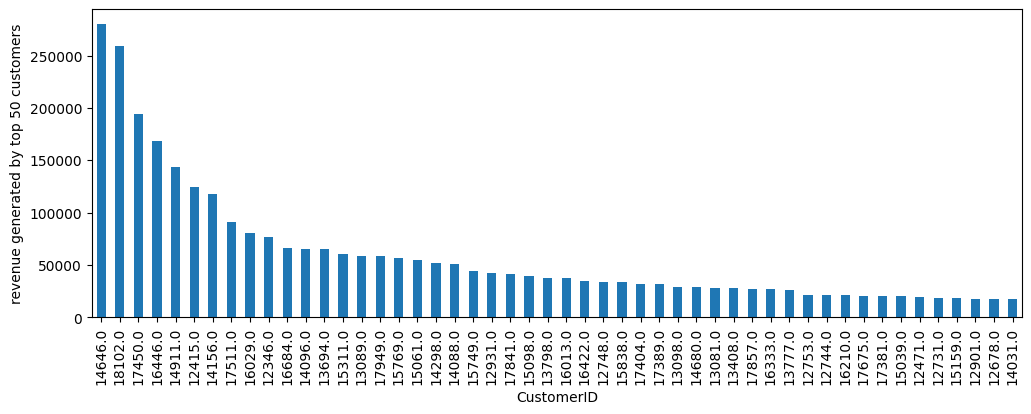

In [33]:
plt.figure(figsize= (12,4))
customer_revenue.sort_values(ascending=False).head(50).plot(kind='bar')
plt.ylabel("revenue generated by top 50 customers")
plt.show()

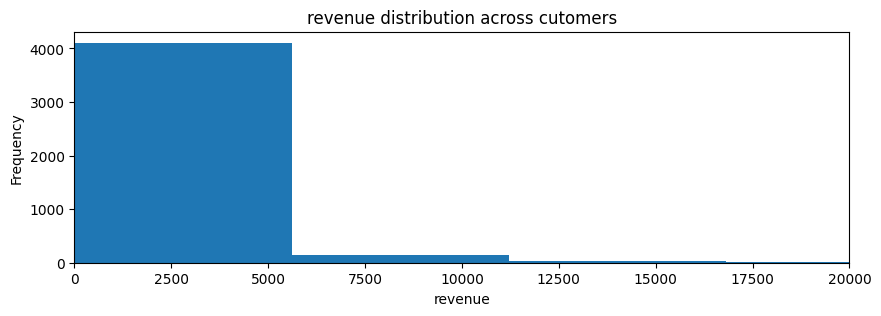

In [46]:
plt.figure(figsize=(10,3))
customer_revenue.plot(kind='hist',bins = 50)
plt.xlim(0,20000)
plt.title("revenue distribution across cutomers")
plt.xlabel("revenue")
plt.show()

# Calculating with purchase count
## repeat ratio

In [48]:
purchase_count = df.groupby("CustomerID")["InvoiceNo"].nunique()

In [52]:
purchase_count.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [57]:
one_time = (purchase_count == 1).sum()
repeat = (purchase_count > 1).sum()

In [63]:
print("one time buyers ",one_time)
print("repeat buyers ", repeat)

one time buyers  1493
repeat buyers  2845


In [66]:
repeat_ratio = repeat/(repeat+one_time) * 100

In [80]:
print(f"{repeat_ratio:.2f}%")

65.58%


retention is happening, so clv can make the customers repeat their purchases

## revenue by country

In [82]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

In [84]:
country_revenue.info()

<class 'pandas.Series'>
Index: 37 entries, United Kingdom to Saudi Arabia
Series name: Revenue
Non-Null Count  Dtype  
--------------  -----  
37 non-null     float64
dtypes: float64(1)
memory usage: 1.6+ KB


In [85]:
country_revenue.head()

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Name: Revenue, dtype: float64

In [89]:
top_countries = country_revenue.head(10)

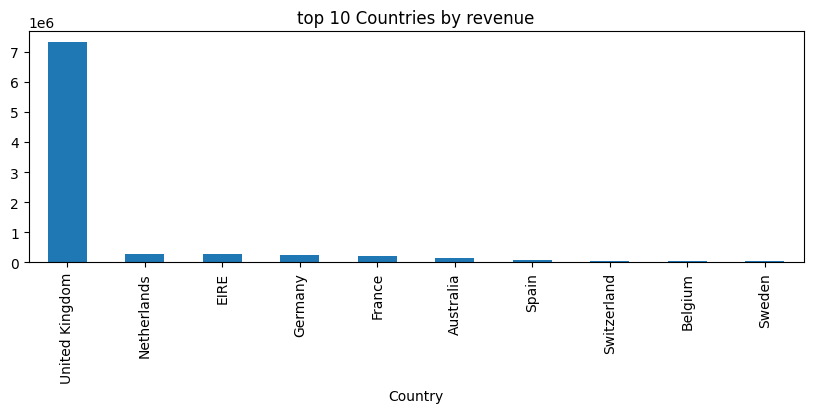

In [91]:
plt.figure(figsize=(10,3))
top_countries.plot(kind="bar")
plt.title("top 10 Countries by revenue")
plt.show()

In [92]:
df.to_csv("data/cleaned_data.csv", index=False)